In [20]:
# Large Cars Dataset 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("D:\\advancedML\\Datasets\\Large Cars Dataset.csv")
df.head()

,Brand,Model,VehicleClass,Region,DriveTrain,MSRP,DealerCost,EngineSize,Cylinders,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,Acura,MDX,SUV,Asia,All,"$36,945","$33,337",3.5,6.0,265,17,23,4451,106,189
1,Acura,RSX Type S 2dr,Sedan,Asia,Front,"$23,820","$21,761",2.0,4.0,200,24,31,2778,101,172
2,Acura,TSX 4dr,Sedan,Asia,Front,"$26,990","$24,647",2.4,4.0,200,22,29,3230,105,183
3,Acura,TL 4dr,Sedan,Asia,Front,"$33,195","$30,299",3.2,6.0,270,20,28,3575,108,186
4,Acura,3.5 RL 4dr,Sedan,Asia,Front,"$43,755","$39,014",3.5,6.0,225,18,24,3880,115,197


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         428 non-null    object 
 1   Model         428 non-null    object 
 2   VehicleClass  428 non-null    object 
 3   Region        428 non-null    object 
 4   DriveTrain    428 non-null    object 
 5   MSRP          428 non-null    object 
 6   DealerCost    428 non-null    object 
 7   EngineSize    428 non-null    float64
 8   Cylinders     426 non-null    float64
 9   HorsePower    428 non-null    int64  
 10  MPG_City      428 non-null    int64  
 11  MPG_Highway   428 non-null    int64  
 12  Weight        428 non-null    int64  
 13  Wheelbase     428 non-null    int64  
 14  Length        428 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 50.3+ KB


In [8]:
df['MSRP'] = df['MSRP'].replace('[\$,]', '', regex=True).astype(float)
df['DealerCost'] = df['DealerCost'].replace('[\$,]', '', regex=True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_15716\3357615479.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['MSRP'] = df['MSRP'].replace('[\$,]', '', regex=True).astype(float)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_15716\3357615479.py:2: SyntaxWarning: invalid escape sequence '\$'
  df['DealerCost'] = df['DealerCost'].replace('[\$,]', '', regex=True).astype(float)


In [9]:
# Handle missing values (Cylinders has 2 missing)
df['Cylinders'] = df['Cylinders'].fillna(df['Cylinders'].median())

In [10]:
# Select numerical features for clustering
features = ['EngineSize', 'Cylinders', 'HorsePower', 'MPG_City', 
            'MPG_Highway', 'Weight', 'Wheelbase', 'Length', 'MSRP']

In [11]:
X = df[features]

print(f"Dataset loaded with {X.shape[0]} rows and {X.shape[1]} features.")
X.head()

Dataset loaded with 428 rows and 9 features.


,EngineSize,Cylinders,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length,MSRP
0,3.5,6.0,265,17,23,4451,106,189,36945.0
1,2.0,4.0,200,24,31,2778,101,172,23820.0
2,2.4,4.0,200,22,29,3230,105,183,26990.0
3,3.2,6.0,270,20,28,3575,108,186,33195.0
4,3.5,6.0,225,18,24,3880,115,197,43755.0


In [12]:
# Scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Generate the Linkage Matrix (using Ward's method)
Z = linkage(X_scaled, method='ward')

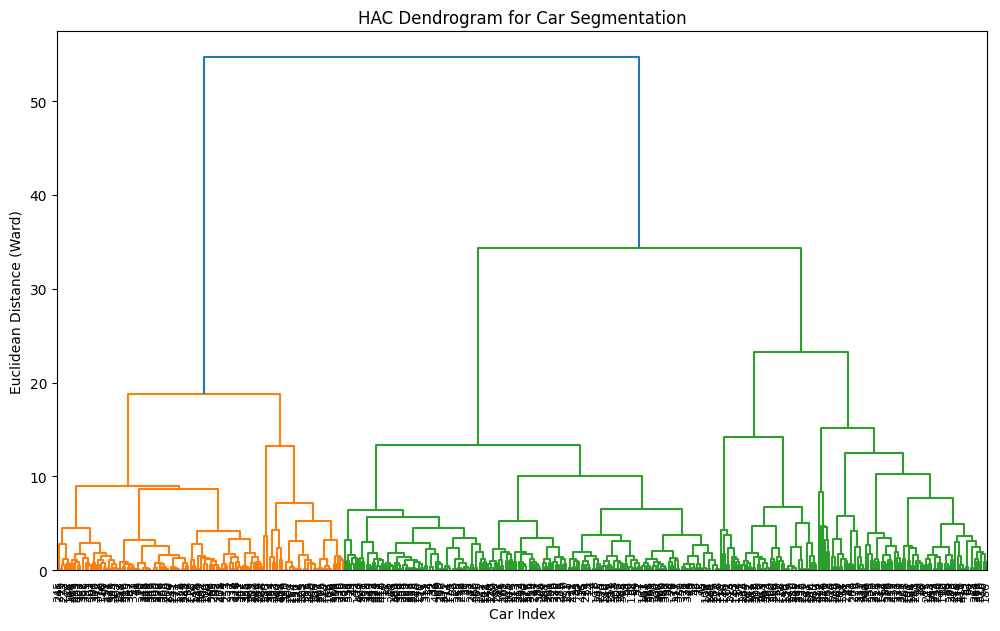

In [13]:
# Plot Dendrogram
plt.figure(figsize=(12, 7))
dendrogram(Z, leaf_rotation=90, leaf_font_size=8)
plt.title('HAC Dendrogram for Car Segmentation')
plt.xlabel('Car Index')
plt.ylabel('Euclidean Distance (Ward)')
plt.show()

In [14]:
scores = []
k_range = range(2, 10)

In [15]:
for k in k_range:
    cluster = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    labels = cluster.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f"Silhouette Score for k={k}: {score:.4f}")

Silhouette Score for k=2: 0.3511
Silhouette Score for k=3: 0.2850
Silhouette Score for k=4: 0.3023
Silhouette Score for k=5: 0.2622
Silhouette Score for k=6: 0.2698
Silhouette Score for k=7: 0.2587
Silhouette Score for k=8: 0.2160
Silhouette Score for k=9: 0.2161


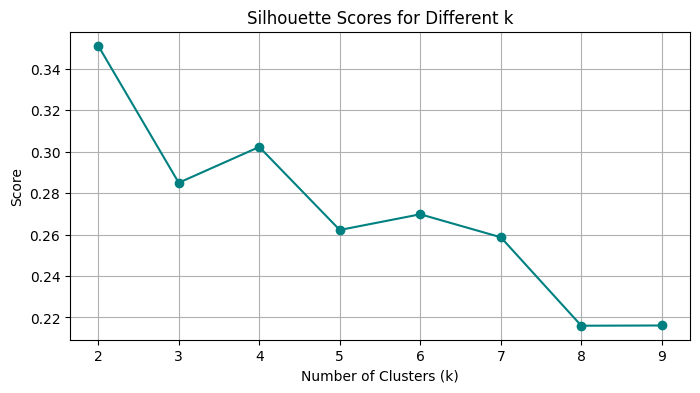

In [16]:
# Plot Silhouette Scores
plt.figure(figsize=(8, 4))
plt.plot(k_range, scores, marker='o', color='teal')
plt.title('Silhouette Scores for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')
plt.grid(True)
plt.show()

In [17]:
# Fit final model
n_clusters = 3 
hac = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
df['Cluster'] = hac.fit_predict(X_scaled)

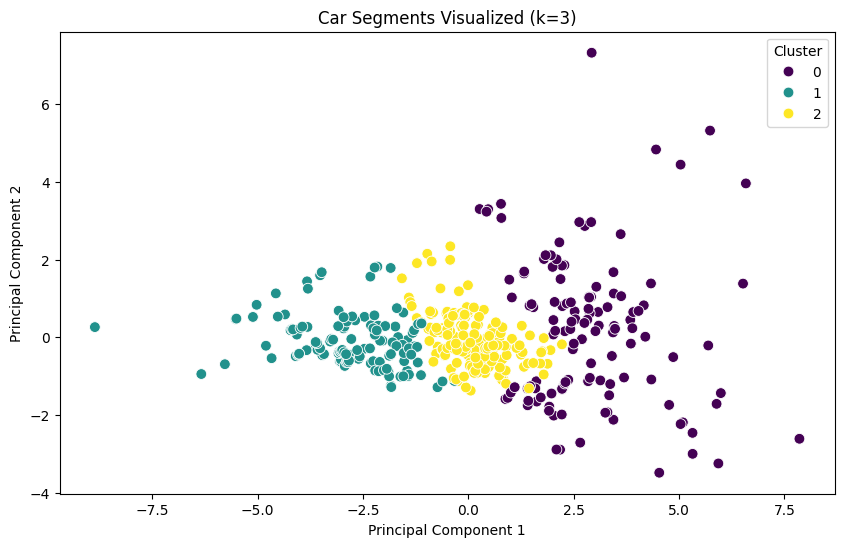

In [18]:
# PCA for 2D Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='viridis', s=60)
plt.title(f'Car Segments Visualized (k={n_clusters})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [19]:
# Analyze the means of each cluster
cluster_analysis = df.groupby('Cluster')[features].mean()
print("Average Values per Cluster:")
display(cluster_analysis)

# Optional: See which Brands end up in which cluster
print("\nTop Brands in each Cluster:")
for i in range(n_clusters):
    print(f"\nCluster {i} typical brands:")
    print(df[df['Cluster'] == i]['Brand'].value_counts().head(3))

Average Values per Cluster:


,EngineSize,Cylinders,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length,MSRP
Cluster,,,,,,,,,
0,4.510569,7.626016,293.056911,15.983740,22.040650,4327.626016,115.178862,197.739837,50715.715447
1,2.050000,3.992424,145.848485,25.416667,32.318182,2860.113636,102.015152,175.734848,19153.393939
2,3.137572,5.901734,214.456647,18.872832,26.080925,3592.664740,107.843931,186.381503,30412.468208



Top Brands in each Cluster:

Cluster 0 typical brands:
Brand
Mercedes-Benz    14
Ford             10
Jaguar            9
Name: count, dtype: int64

Cluster 1 typical brands:
Brand
Toyota    14
Honda     12
Subaru     8
Name: count, dtype: int64

Cluster 2 typical brands:
Brand
BMW          14
Chevrolet    12
Audi         10
Name: count, dtype: int64
